<div style="background:linear-gradient(135deg,#FF5A5F 0%,#C0392B 100%);padding:48px 40px 36px 40px;border-radius:12px;margin-bottom:4px">
<h1 style="color:#fff;font-family:'Segoe UI',sans-serif;font-size:2.4rem;margin:0 0 10px 0;font-weight:700;letter-spacing:-0.5px">
  Airbnb Market &amp; Pricing Intelligence
</h1>
<p style="color:rgba(255,255,255,0.88);font-size:1.05rem;margin:0 0 20px 0;font-style:italic">
  Data-Driven Analysis of Listings, Pricing, Locations, Hosts and Reviews
</p>
<div style="display:flex;flex-wrap:wrap;gap:10px;margin-top:6px">
  <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;border-radius:20px;font-size:0.82rem;font-weight:600">IBM SkillsBuild Data Analytics Internship</span>
  <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;border-radius:20px;font-size:0.82rem;font-weight:600">Deepanshu Gautam</span>
  <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;border-radius:20px;font-size:0.82rem;font-weight:600">Python · Pandas · Matplotlib · Seaborn · Plotly</span>
</div>
</div>


---
## 📋 Executive Summary

This notebook presents a comprehensive **market and pricing intelligence analysis** of the Airbnb platform across **10 global cities**, using two datasets comprising over **279,000 listings** and **5.3 million reviews**.

| # | Business Question |
|---|------------------|
| 1 | How are Airbnb listings distributed across different cities and neighbourhoods? |
| 2 | What are the pricing patterns by city, room type, property type and guest capacity? |
| 3 | How does Superhost status relate to listing price and review score differences? |
| 4 | How do review scores differ across markets and property segments? |
| 5 | How has review activity evolved from 2008–2021, and what does it signal? |
| 6 | What are the key actionable opportunities for hosts and marketplace stakeholders? |

> **⚠️ Disclaimer:** This dataset contains *advertised listing prices* set by hosts. It does **not** contain actual booking revenue, occupancy rates, or realized transaction data. All pricing figures represent listing prices only.


---
# 1 · Business Context & Objectives

## 1.1 Business Problem

Airbnb operates a two-sided marketplace connecting property hosts with travellers worldwide. Both hosts and market analysts face persistent information asymmetries:

- **Hosts** lack visibility into competitive pricing across their local market
- **Platform operators** need to understand supply distribution and quality signals across cities
- **Researchers and analysts** need to benchmark city-level marketplace maturity and growth

This analysis simulates the work of a **Marketplace Intelligence Analyst** examining Airbnb listing data to surface pricing, quality, and supply patterns across ten major global cities.

## 1.2 Objectives

1. **Supply Analysis** — Map listing distribution by city, room type, property type and neighbourhood
2. **Pricing Intelligence** — Quantify price variation across markets, property segments and guest capacity
3. **Host Performance** — Compare Superhost vs. regular host metrics across multiple dimensions
4. **Quality Signals** — Analyse review scores across categories, cities and listing types
5. **Review Activity** — Examine temporal trends in review volume as a proxy for platform engagement
6. **Recommendations** — Derive practical, data-backed business recommendations

## 1.3 Analytical Approach

```
Data Loading → Quality Audit → Cleaning → Feature Engineering
     ↓                                            ↓
EDA (Supply · Price · Host · Reviews)     Cross-Analysis
     ↓                                            ↓
Key Findings → Business Recommendations → Limitations
```

All conclusions are derived directly from the data. Associative observations are clearly distinguished from causal claims.


---
# 2 · Environment & Imports


In [1]:
# ── Standard library ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# ── Data manipulation ────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Display settings ─────────────────────────────────────────────────────
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_rows", 80)

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Colour palette ───────────────────────────────────────────────────────
AIRBNB_RED  = "#FF5A5F"
AIRBNB_TEAL = "#00A699"
AIRBNB_ORG  = "#FC642D"
NEUTRAL     = "#484848"

# ── Dataset paths ────────────────────────────────────────────────────────
DATA_DIR      = Path(".")
LISTINGS_PATH = DATA_DIR / "Listings.csv"
REVIEWS_PATH  = DATA_DIR / "Reviews.csv"

import plotly
print("✅  All imports successful")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}  |  "
      f"matplotlib  {matplotlib.__version__}  |  plotly  {plotly.__version__}")


✅  All imports successful
   pandas  3.0.0  |  numpy  2.4.2  |  matplotlib  3.10.8  |  plotly  7.1.0


---
# 3 · Data Loading & Initial Inspection


In [2]:
LISTINGS_USECOLS = [
    "listing_id", "name", "host_id", "host_since",
    "host_response_time", "host_response_rate", "host_acceptance_rate",
    "host_is_superhost", "host_total_listings_count",
    "host_has_profile_pic", "host_identity_verified",
    "neighbourhood", "city", "latitude", "longitude",
    "property_type", "room_type", "accommodates", "bedrooms",
    "amenities", "price", "minimum_nights", "maximum_nights",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value", "instant_bookable",
]

listings_raw = pd.read_csv(
    LISTINGS_PATH,
    encoding="latin-1",
    usecols=LISTINGS_USECOLS,
    low_memory=False,
)

print(f"Listings loaded : {listings_raw.shape[0]:,} rows  ×  {listings_raw.shape[1]} columns")
print(f"Memory usage    : {listings_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Listings loaded : 279,712 rows  ×  31 columns
Memory usage    : 185.4 MB


In [3]:
# Reviews — load only the two needed columns to keep memory low
reviews_raw = pd.read_csv(
    REVIEWS_PATH,
    usecols=["listing_id", "date"],
    parse_dates=["date"],
    dtype={"listing_id": "int32"},
)

print(f"Reviews loaded  : {len(reviews_raw):,} rows")
print(f"Date range      : {reviews_raw['date'].min().date()}  →  {reviews_raw['date'].max().date()}")


Reviews loaded  : 5,373,143 rows
Date range      : 2008-11-16  →  2021-03-01


In [4]:
# Dataset summary card
summary = pd.DataFrame({
    "Dataset"     : ["Listings.csv", "Reviews.csv"],
    "Rows"        : [f"{len(listings_raw):,}", f"{len(reviews_raw):,}"],
    "Columns"     : [listings_raw.shape[1], reviews_raw.shape[1]],
    "Size on disk": ["~55 MB", "~155 MB"],
    "Date Span"   : ["host_since: 2008–2021", f"reviews: {reviews_raw['date'].min().year}–{reviews_raw['date'].max().year}"],
})
print("=== Dataset Overview ===\n")
print(summary.to_string(index=False))


=== Dataset Overview ===

     Dataset      Rows  Columns Size on disk             Date Span
Listings.csv   279,712       31       ~55 MB host_since: 2008–2021
 Reviews.csv 5,373,143        2      ~155 MB    reviews: 2008–2021


In [5]:
print("── Listings: first 3 rows ──")
listings_raw.head(3)


── Listings: first 3 rows ──


,listing_id,name,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,NaN,NaN,NaN,f,1.00,t,f,Buttes-Montmartre,Paris,48.89,2.33,Entire apartment,Entire place,2,1.00,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,NaN,NaN,NaN,f,1.00,t,t,Buttes-Montmartre,Paris,48.89,2.35,Entire apartment,Entire place,2,1.00,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,NaN,NaN,NaN,f,1.00,t,f,Elysee,Paris,48.88,2.32,Entire apartment,Entire place,2,1.00,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.00,10.00,10.00,10.00,10.00,10.00,10.00,f


---
# 4 · Data Understanding
## 4.1 Column Reference


In [6]:
# Column-level metadata table
meta = pd.DataFrame({
    "Column"       : listings_raw.columns,
    "Dtype"        : listings_raw.dtypes.astype(str).values,
    "Non-Null"     : listings_raw.notna().sum().values,
    "Null Count"   : listings_raw.isna().sum().values,
    "Null %"       : (listings_raw.isna().mean() * 100).round(1).values,
    "Sample Value" : [str(listings_raw[c].dropna().iloc[0])
                      if listings_raw[c].notna().any() else "—"
                      for c in listings_raw.columns],
})
meta.style.background_gradient(subset=["Null %"], cmap="YlOrRd").format({"Null %": "{:.1f}%"})


,Column,Dtype,Non-Null,Null Count,Null %,Sample Value
0,listing_id,int64,279712,0,0.0%,281420
1,name,str,279537,175,0.1%,"Beautiful Flat in le Village Montmartre, Paris"
2,host_id,int64,279712,0,0.0%,1466919
3,host_since,str,279547,165,0.1%,2011-12-03
4,host_response_time,str,150930,128782,46.0%,within a few hours
5,host_response_rate,float64,150930,128782,46.0%,1.0
6,host_acceptance_rate,float64,166625,113087,40.4%,1.0
7,host_is_superhost,str,279547,165,0.1%,f
8,host_total_listings_count,float64,279547,165,0.1%,1.0
9,host_has_profile_pic,str,279547,165,0.1%,t


## 4.2 City & Market Distribution


In [7]:
city_raw = listings_raw["city"].value_counts().reset_index()
city_raw.columns = ["City", "Listings"]
city_raw["Share (%)"] = (city_raw["Listings"] / city_raw["Listings"].sum() * 100).round(1)
city_raw["Cumulative (%)"] = city_raw["Share (%)"].cumsum().round(1)
print(city_raw.to_string(index=False))


          City  Listings  Share (%)  Cumulative (%)
         Paris     64690      23.10           23.10
      New York     37012      13.20           36.30
        Sydney     33630      12.00           48.30
          Rome     27647       9.90           58.20
Rio de Janeiro     26615       9.50           67.70
      Istanbul     24519       8.80           76.50
   Mexico City     20065       7.20           83.70
       Bangkok     19361       6.90           90.60
     Cape Town     19086       6.80           97.40
     Hong Kong      7087       2.50           99.90


---
# 5 · Data Quality Audit

A systematic audit before any cleaning decisions are made.


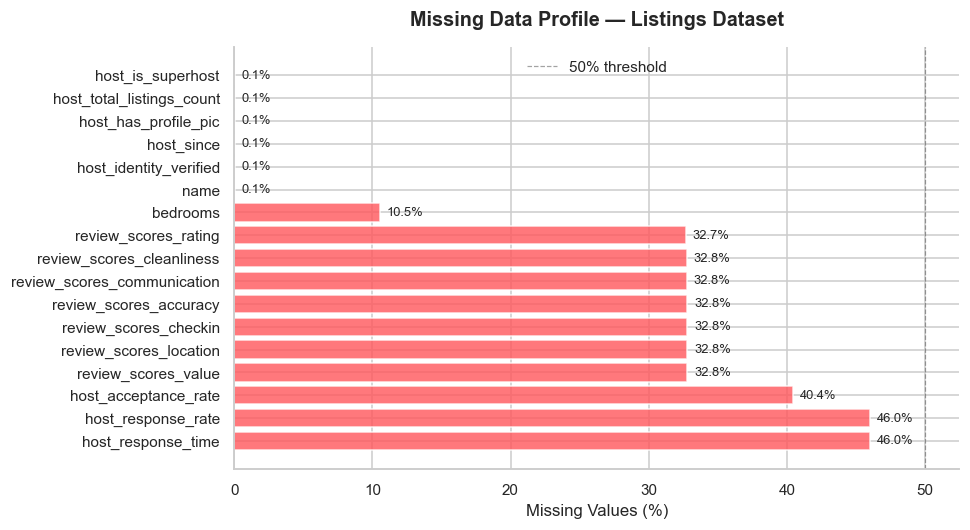

In [8]:
# 5.1 Missing value visualisation
null_df = listings_raw.isnull().sum().reset_index()
null_df.columns = ["Column", "Missing Count"]
null_df["Missing %"] = (null_df["Missing Count"] / len(listings_raw) * 100).round(2)
null_df = null_df[null_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(null_df["Column"], null_df["Missing %"],
               color=AIRBNB_RED, alpha=0.82, edgecolor="white")
ax.set_xlabel("Missing Values (%)")
ax.set_title("Missing Data Profile — Listings Dataset", fontweight="bold", pad=14)
ax.axvline(50, ls="--", color=NEUTRAL, lw=0.8, alpha=0.5, label="50% threshold")
for b in bars:
    w = b.get_width()
    ax.text(w + 0.5, b.get_y() + b.get_height()/2, f"{w:.1f}%",
            va="center", ha="left", fontsize=8.5)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [9]:
# 5.2 Price sanity check
print("Price statistics (raw):")
print(listings_raw["price"].describe().to_string())
print(f"\nZero-price rows    : {(listings_raw['price'] == 0).sum()}")
print(f"99.9th percentile  : {listings_raw['price'].quantile(0.999):,.0f}")
print(f"Max price          : {listings_raw['price'].max():,.0f}")

# 5.3 Duplicate check
print(f"\nDuplicate listing_id rows : {listings_raw['listing_id'].duplicated().sum()}")

# 5.4 Accommodates = 0 check
zero_acc = (pd.to_numeric(listings_raw["accommodates"], errors="coerce") == 0).sum()
print(f"Accommodates = 0 rows     : {zero_acc}")


Price statistics (raw):
count   279,712.00
mean        608.79
std       3,441.83
min           0.00
25%          75.00
50%         150.00
75%         474.00
max     625,216.00

Zero-price rows    : 113
99.9th percentile  : 32,178
Max price          : 625,216

Duplicate listing_id rows : 0
Accommodates = 0 rows     : 85


### Quality Audit Summary

| Dimension | Finding | Planned Action |
|-----------|---------|----------------|
| Duplicate listing IDs | 0 duplicates | No action needed |
| Missing: `host_response_time/rate` | ~46% missing | Retain; note in host analysis |
| Missing: `host_acceptance_rate` | ~40% missing | Retain; flag in host analysis |
| Missing: `review_scores_*` | ~33% missing | Retain rated subset; report coverage |
| Missing: `bedrooms` | ~11% missing | Impute with median per property type |
| Missing: `host_is_superhost` | <0.1% | Drop in host-specific analyses |
| Price = 0 | 113 rows | Remove (invalid listing price) |
| Price extreme outliers | Max 625K; 99.9th pctile ~32K | Cap at 99.9th percentile |
| `accommodates` = 0 | 85 rows | Exclude from price-per-person calculation |


---
# 6 · Data Cleaning


In [10]:
listings = listings_raw.copy()
print(f"Starting shape: {listings.shape}")

# 6.1 Boolean columns
for col in ["host_is_superhost", "host_has_profile_pic",
            "host_identity_verified", "instant_bookable"]:
    listings[col] = listings[col].map({"t": True, "f": False})

# 6.2 Date conversion
listings["host_since"]      = pd.to_datetime(listings["host_since"], errors="coerce")
listings["host_since_year"] = listings["host_since"].dt.year.astype("Int16")

# 6.3 Numeric coercion
for col in ["bedrooms", "price", "accommodates", "host_total_listings_count",
            "host_response_rate", "host_acceptance_rate"]:
    listings[col] = pd.to_numeric(listings[col], errors="coerce")

# 6.4 Remove invalid prices
n_before    = len(listings)
listings    = listings[listings["price"] > 0].copy()
price_cap   = listings["price"].quantile(0.999)
listings    = listings[listings["price"] <= price_cap].copy()
print(f"Removed {n_before - len(listings):,} rows (zero price + extreme outliers)")

# 6.5 Impute missing bedrooms with median per property_type
med_by_pt = listings.groupby("property_type")["bedrooms"].transform("median")
listings["bedrooms"] = listings["bedrooms"].fillna(med_by_pt)
listings["bedrooms"] = listings["bedrooms"].fillna(listings["bedrooms"].median())

# 6.6 Amenity count
listings["amenity_count"] = listings["amenities"].str.count(",") + 1

print(f"Final cleaned shape: {listings.shape}")
print(f"\nPrice statistics (cleaned):")
print(listings["price"].describe().to_string())


Starting shape: (279712, 31)
Removed 393 rows (zero price + extreme outliers)
Final cleaned shape: (279319, 33)

Price statistics (cleaned):
count   279,319.00
mean        532.58
std       1,388.88
min           1.00
25%          75.00
50%         150.00
75%         470.00
max      32,047.00


---
# 7 · Feature Engineering


In [11]:
# 7.1 price_per_person (exclude accommodates < 1)
listings["price_per_person"] = np.where(
    listings["accommodates"] >= 1,
    listings["price"] / listings["accommodates"],
    np.nan
)

# 7.2 property_type_group
# "Serviced apartment" checked FIRST to avoid misclassification as plain Apartment
def group_property_type(pt: str) -> str:
    pt = str(pt).lower()
    if "serviced apartment" in pt:            return "Serviced Apartment"
    if "apartment" in pt or "condo" in pt or "loft" in pt:
                                              return "Apartment / Condo / Loft"
    if ("house" in pt or "villa" in pt or
        "townhouse" in pt or "cottage" in pt):return "House / Villa / Townhouse"
    if "hotel" in pt or "aparthotel" in pt or "boutique" in pt:
                                              return "Hotel / Boutique"
    if "bed and breakfast" in pt or "guesthouse" in pt:
                                              return "B&B / Guesthouse"
    if "guest suite" in pt:                   return "Guest Suite"
    return "Other"

listings["property_group"] = listings["property_type"].apply(group_property_type)

# 7.3 host_portfolio_tier
def portfolio_tier(n):
    if n == 1:   return "1 listing (solo)"
    if n <= 10:  return "2–10 listings"
    if n <= 50:  return "11–50 listings"
    return "50+ listings"

listings["host_tier"] = (
    listings["host_total_listings_count"].fillna(1).astype(int).apply(portfolio_tier)
)

print("New features — value counts:")
for col in ["property_group", "host_tier"]:
    print(f"\n{col}:")
    print(listings[col].value_counts().to_string())


New features — value counts:

property_group:
property_group
Apartment / Condo / Loft     210152
House / Villa / Townhouse     38359
Hotel / Boutique              10389
Serviced Apartment             6413
B&B / Guesthouse               5481
Other                          4835
Guest Suite                    3690

host_tier:
host_tier
2–10 listings       125276
1 listing (solo)    117658
11–50 listings       24065
50+ listings         12320


In [12]:
# 7.4 Reviews temporal features
reviews_raw["year"]       = reviews_raw["date"].dt.year.astype("int16")
reviews_raw["month"]      = reviews_raw["date"].dt.month.astype("int8")
reviews_raw["year_month"] = reviews_raw["date"].dt.to_period("M").astype(str)

yearly_reviews  = reviews_raw.groupby("year").size().reset_index(name="review_count")
monthly_reviews = (
    reviews_raw.groupby("year_month").size()
    .reset_index(name="review_count")
    .sort_values("year_month")
)
listing_review_counts = (
    reviews_raw.groupby("listing_id").size()
    .reset_index(name="review_count")
)
listing_review_counts["listing_id"] = listing_review_counts["listing_id"].astype("int64")

# Release raw reviews from memory
del reviews_raw

print(f"Yearly review table  : {yearly_reviews.shape}")
print(f"Monthly review table : {monthly_reviews.shape}")
print(f"Per-listing counts   : {listing_review_counts.shape}")


Yearly review table  : (14, 2)
Monthly review table : (147, 2)
Per-listing counts   : (193556, 2)


---
# 8 · Exploratory Data Analysis — Supply & Distribution


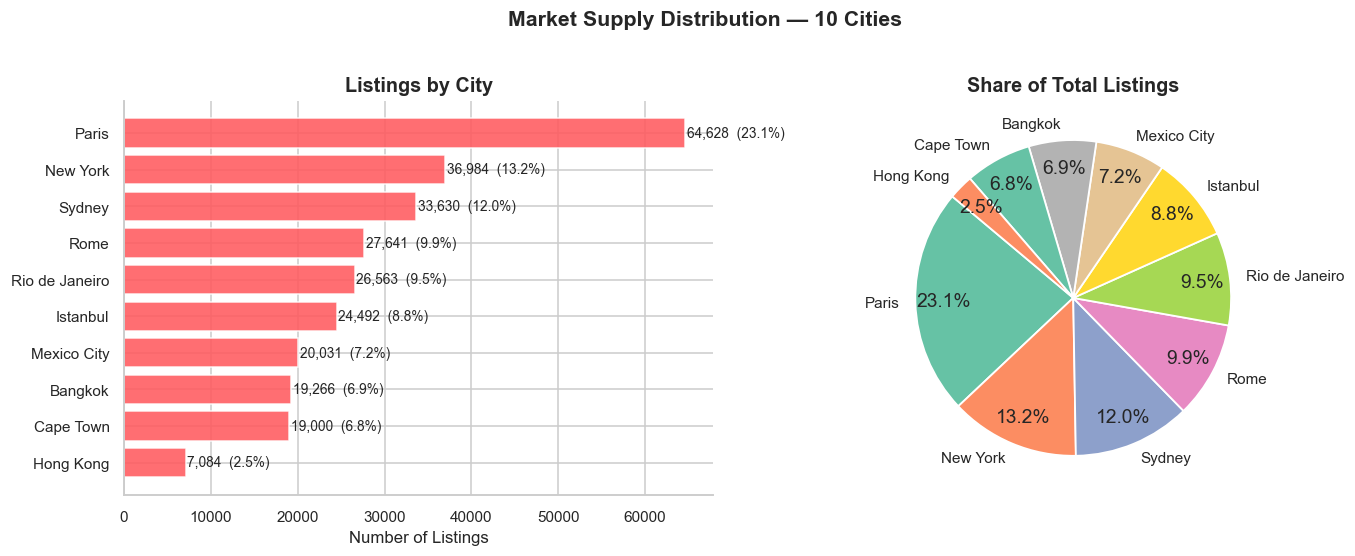

In [13]:
# 8.1 Listings by city
city_counts = listings["city"].value_counts().reset_index()
city_counts.columns = ["city", "count"]
city_counts["pct"] = (city_counts["count"] / len(listings) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(city_counts["city"][::-1], city_counts["count"][::-1],
             color=AIRBNB_RED, edgecolor="white", alpha=0.88)
axes[0].set_xlabel("Number of Listings")
axes[0].set_title("Listings by City", fontweight="bold")
for i, (v, p) in enumerate(zip(city_counts["count"][::-1], city_counts["pct"][::-1])):
    axes[0].text(v + 200, i, f"{v:,}  ({p}%)", va="center", fontsize=9)

axes[1].pie(city_counts["count"], labels=city_counts["city"], autopct="%1.1f%%",
            colors=sns.color_palette("Set2", n_colors=10),
            startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor="white", linewidth=1.2))
axes[1].set_title("Share of Total Listings", fontweight="bold")

plt.suptitle("Market Supply Distribution — 10 Cities", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**📌 Key Observation:** Paris dominates with ~23% of total listings, followed by New York (~13%) and Sydney (~12%). Paris and New York together represent more than a third of the dataset. Hong Kong has the smallest market presence at ~2.5%, which may reflect data coverage differences or a smaller Airbnb footprint.


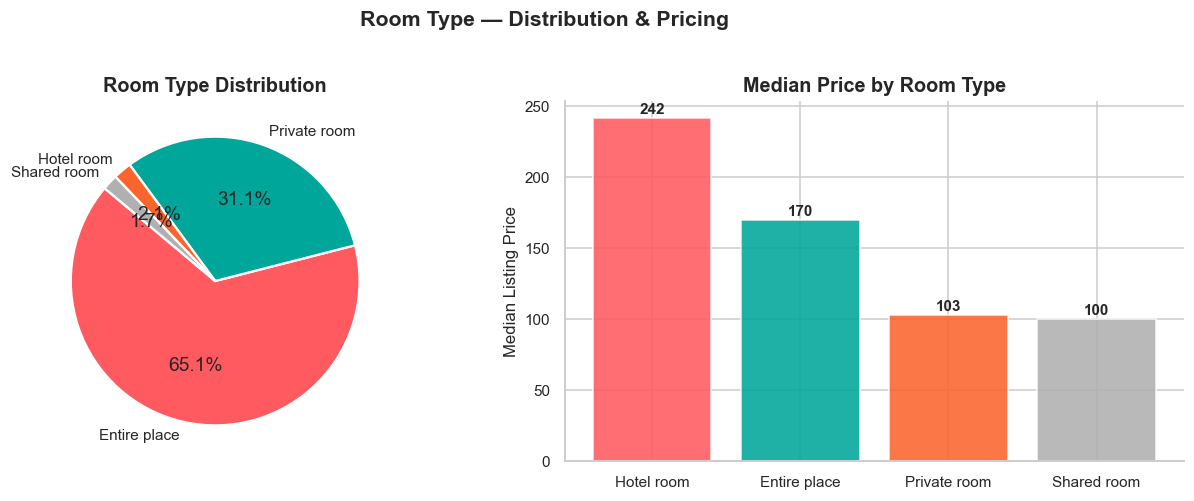

Room type counts:
  Entire place        : 181,819  (65.1%)
  Private room        :  86,910  (31.1%)
  Hotel room          :   5,736  (2.1%)
  Shared room         :   4,854  (1.7%)


In [14]:
# 8.2 Room type distribution
room_counts    = listings["room_type"].value_counts()
room_med_price = listings.groupby("room_type")["price"].median().sort_values(ascending=False)

room_colors = [AIRBNB_RED, AIRBNB_TEAL, AIRBNB_ORG, "#B0B0B0"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].pie(room_counts, labels=room_counts.index, autopct="%1.1f%%",
            colors=room_colors, startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Room Type Distribution", fontweight="bold")

axes[1].bar(room_med_price.index, room_med_price.values,
            color=room_colors[:len(room_med_price)], edgecolor="white", alpha=0.88)
axes[1].set_ylabel("Median Listing Price")
axes[1].set_title("Median Price by Room Type", fontweight="bold")
for i, v in enumerate(room_med_price.values):
    axes[1].text(i, v + 3, f"{v:,.0f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Room Type — Distribution & Pricing", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Room type counts:")
for rt, cnt in room_counts.items():
    print(f"  {rt:<20s}: {cnt:>7,}  ({cnt/len(listings)*100:.1f}%)")


**📌 Key Observation:** Entire-place listings make up **65% of supply** — the dominant format. Private rooms (31%) represent a significant budget-friendly segment. Hotel rooms and Shared rooms together account for only ~4% of supply. Despite lower unit count, Hotel rooms command the highest median price (consistent with premium positioning), while Shared rooms offer the lowest median price.


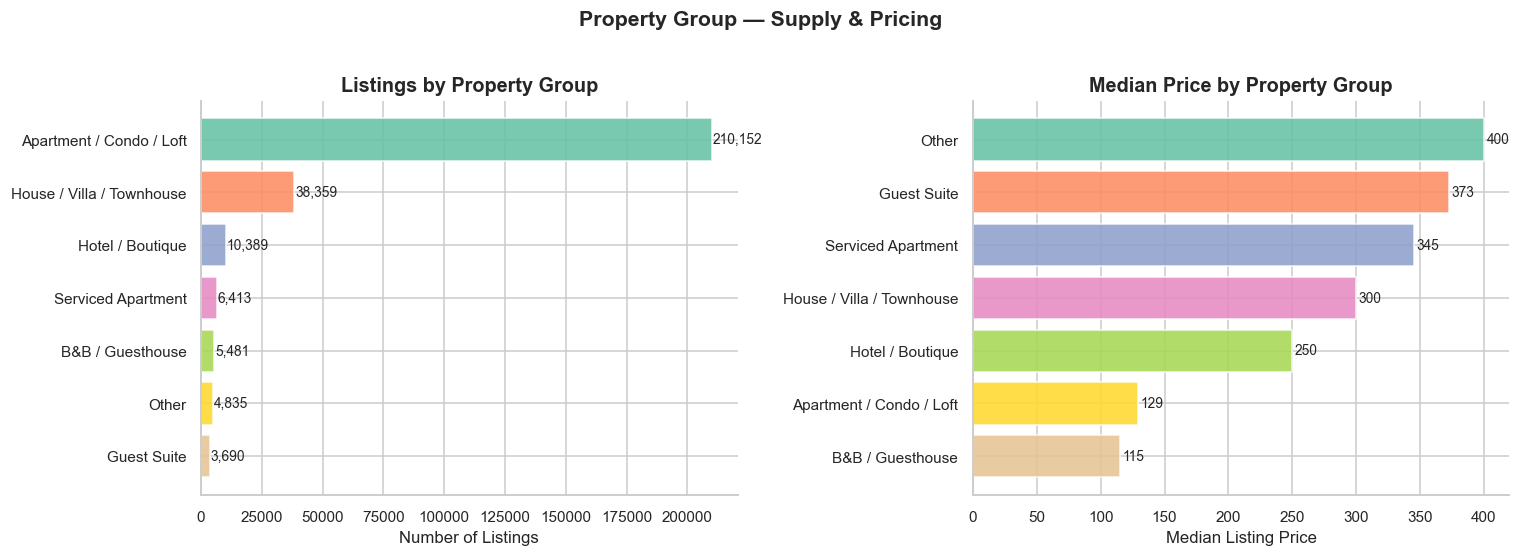

In [15]:
# 8.3 Property group distribution
pg_counts  = listings["property_group"].value_counts()
pg_med_price = listings.groupby("property_group")["price"].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pg = sns.color_palette("Set2", n_colors=len(pg_counts))
axes[0].barh(pg_counts.index[::-1], pg_counts.values[::-1],
             color=colors_pg[::-1], edgecolor="white", alpha=0.88)
axes[0].set_xlabel("Number of Listings")
axes[0].set_title("Listings by Property Group", fontweight="bold")
for b in axes[0].patches:
    w = b.get_width()
    axes[0].text(w + 300, b.get_y() + b.get_height()/2, f"{w:,.0f}", va="center", fontsize=9)

axes[1].barh(pg_med_price.index[::-1], pg_med_price.values[::-1],
             color=colors_pg[::-1], edgecolor="white", alpha=0.88)
axes[1].set_xlabel("Median Listing Price")
axes[1].set_title("Median Price by Property Group", fontweight="bold")
for b in axes[1].patches:
    w = b.get_width()
    axes[1].text(w + 2, b.get_y() + b.get_height()/2, f"{w:,.0f}", va="center", fontsize=9)

plt.suptitle("Property Group — Supply & Pricing", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


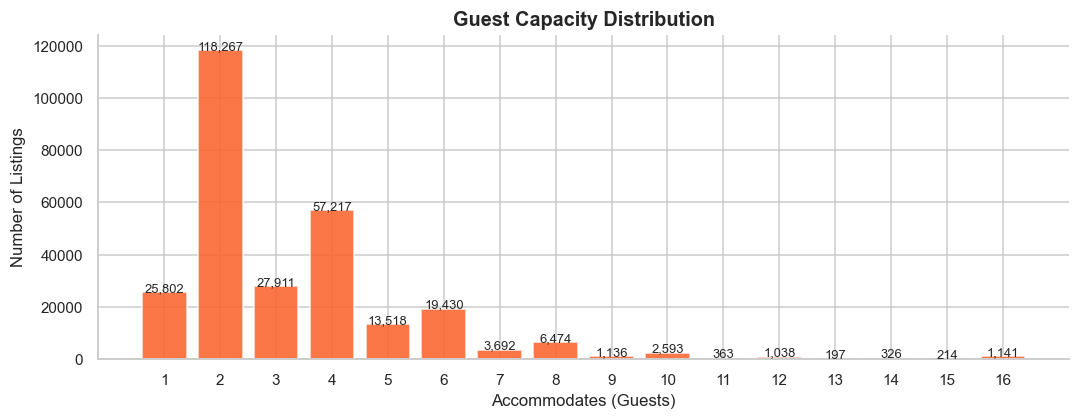

Most common capacity: 2 guests (118,267 listings = 42.3%)


In [16]:
# 8.4 Guest capacity distribution
cap_dist = (listings[listings["accommodates"].between(1, 16)]
            ["accommodates"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cap_dist.index, cap_dist.values, color=AIRBNB_ORG, edgecolor="white", alpha=0.88)
ax.set_xlabel("Accommodates (Guests)")
ax.set_ylabel("Number of Listings")
ax.set_title("Guest Capacity Distribution", fontweight="bold")
ax.set_xticks(cap_dist.index)
for x, y in zip(cap_dist.index, cap_dist.values):
    ax.text(x, y + 200, f"{y:,}", ha="center", fontsize=8.5)
plt.tight_layout()
plt.show()

mode_cap = cap_dist.idxmax()
print(f"Most common capacity: {mode_cap} guests "
      f"({cap_dist[mode_cap]:,} listings = {cap_dist[mode_cap]/len(listings)*100:.1f}%)")


**📌 Key Observation:** The overwhelming majority of listings accommodate **2 guests** (~42%), reflecting the prevalence of couples-oriented studio and 1-bedroom units. The 4-person capacity segment is the second largest, likely corresponding to 2-bedroom apartments suitable for families or small groups.


## 8.5 Neighbourhood Analysis


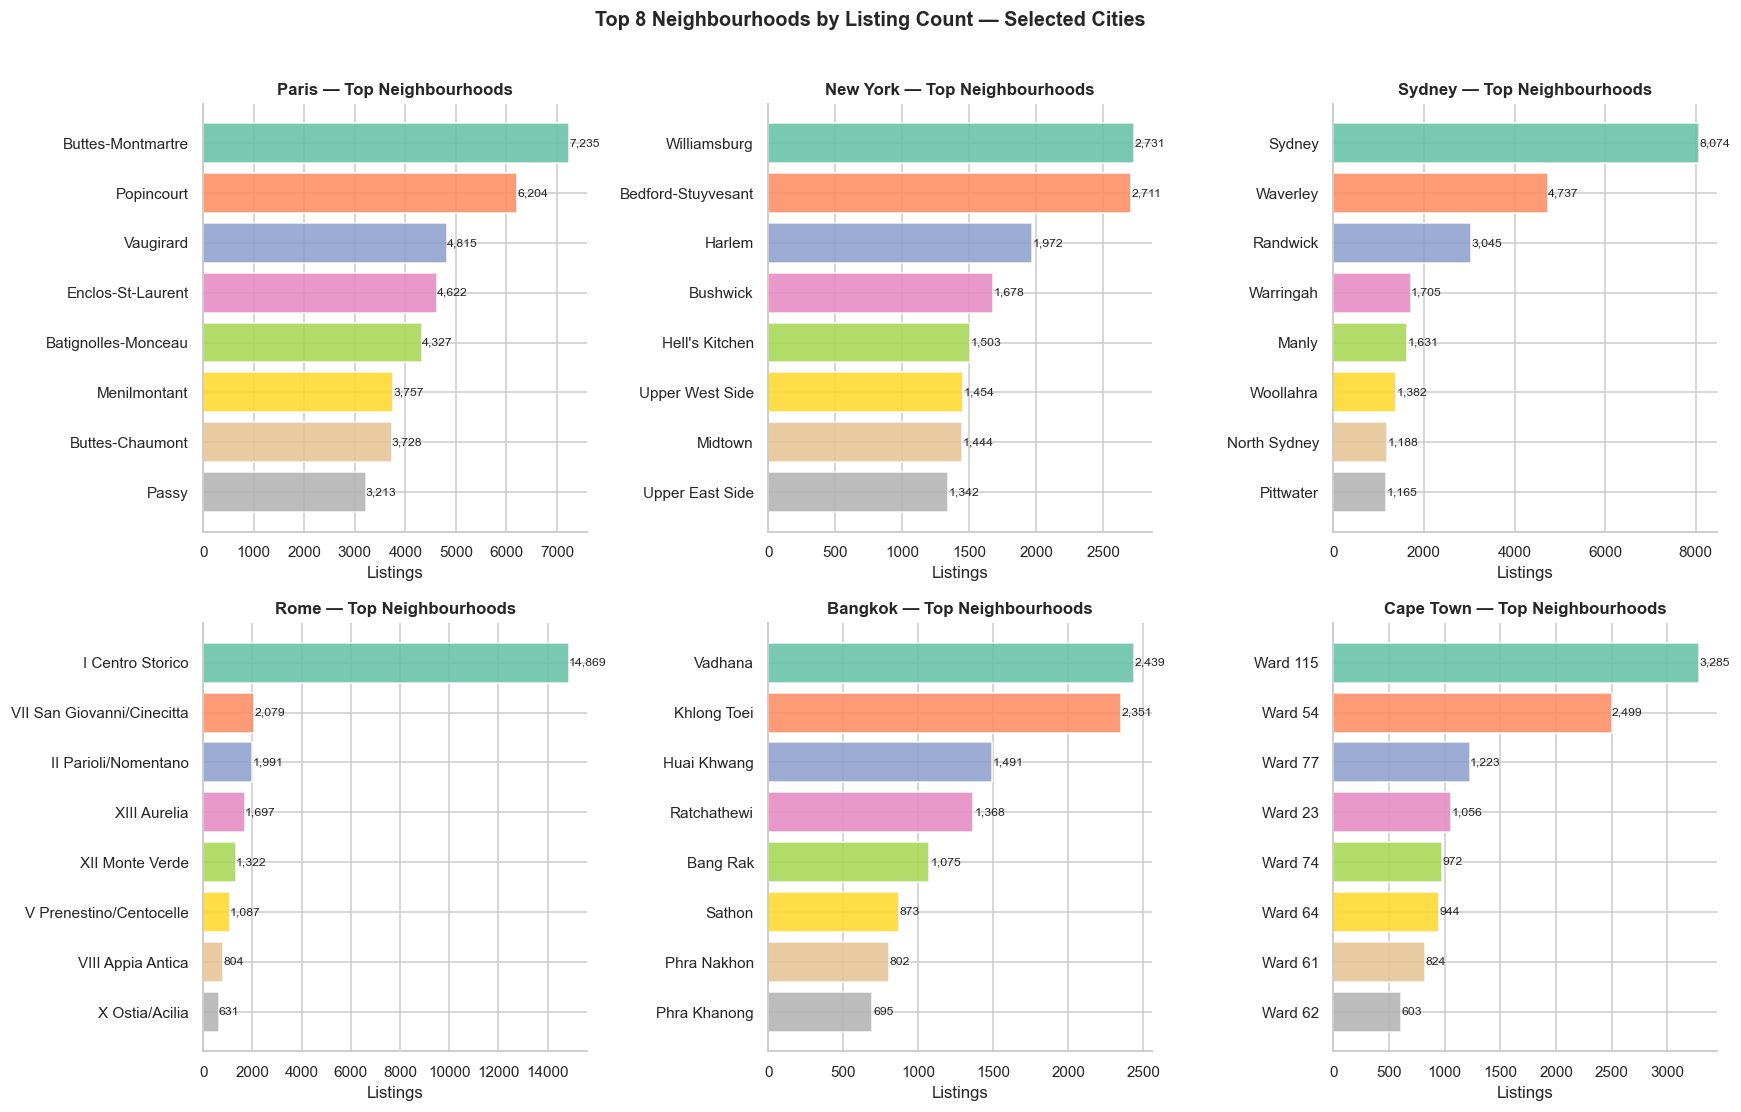

In [17]:
# Top neighbourhoods per city (top 8 each)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
cities_to_plot = ["Paris", "New York", "Sydney", "Rome", "Bangkok", "Cape Town"]

for idx, city in enumerate(cities_to_plot):
    city_df = listings[listings["city"] == city]
    top_n   = city_df["neighbourhood"].value_counts().head(8)
    ax = axes[idx]
    ax.barh(top_n.index[::-1], top_n.values[::-1],
            color=sns.color_palette("Set2", n_colors=8)[::-1],
            edgecolor="white", alpha=0.88)
    ax.set_title(f"{city} — Top Neighbourhoods", fontweight="bold", fontsize=11)
    ax.set_xlabel("Listings")
    for b in ax.patches:
        w = b.get_width()
        ax.text(w + 5, b.get_y() + b.get_height()/2, f"{int(w):,}",
                va="center", fontsize=8)

plt.suptitle("Top 8 Neighbourhoods by Listing Count — Selected Cities",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 8.6 Geographic Distribution — Interactive Map


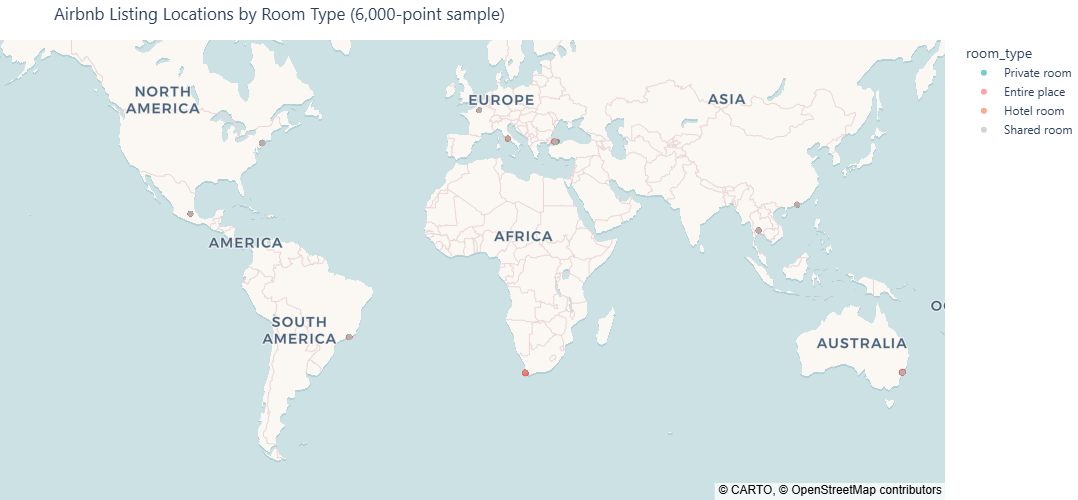

In [18]:
# Sample 6000 points for readable map rendering
map_sample = listings.sample(6000, random_state=42)

fig = px.scatter_map(
    map_sample,
    lat="latitude",
    lon="longitude",
    color="room_type",
    color_discrete_map={
        "Entire place" : AIRBNB_RED,
        "Private room" : AIRBNB_TEAL,
        "Hotel room"   : AIRBNB_ORG,
        "Shared room"  : "#B0B0B0",
    },
    opacity=0.55,
    hover_data={"price": True, "city": True, "neighbourhood": True,
               "latitude": False, "longitude": False},
    zoom=1,
    height=500,
    title="Airbnb Listing Locations by Room Type (6,000-point sample)",
) if hasattr(px, "scatter_map") else px.scatter_mapbox(
    map_sample,
    lat="latitude", lon="longitude", color="room_type",
    color_discrete_map={
        "Entire place": AIRBNB_RED, "Private room": AIRBNB_TEAL,
        "Hotel room": AIRBNB_ORG, "Shared room": "#B0B0B0"},
    opacity=0.55, mapbox_style="carto-positron", zoom=1, height=500,
    title="Airbnb Listing Locations by Room Type (6,000-point sample)",
)

fig.update_layout(margin=dict(l=0, r=0, t=40, b=0),
                  font=dict(family="Segoe UI, sans-serif"))
fig.show()


---
# 9 · Pricing Intelligence

> **Analytical Question:** How do listing prices vary across cities, room types, property types and guest capacity? Where are pricing premiums concentrated, and what structural price relationships exist?


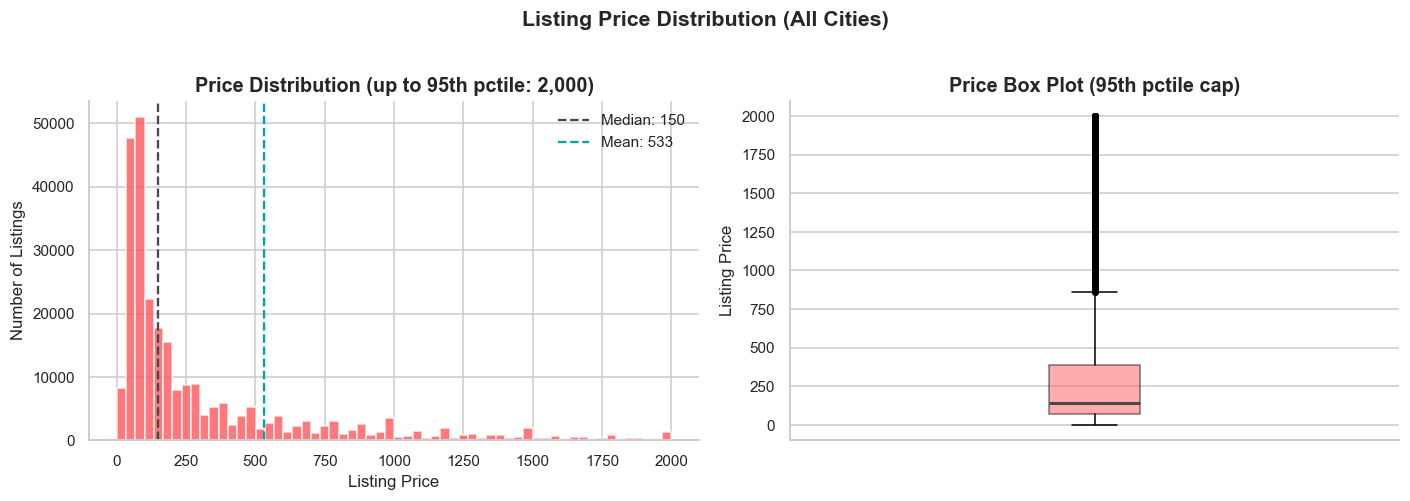

Mean price   :     532.58
Median price :     150.00
Std dev      :   1,388.88

Note: Prices are in local currencies — direct cross-city comparisons should account for exchange rates.


In [19]:
# 9.1 Overall price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Raw distribution (capped at 95th pctile for readability)
p95 = listings["price"].quantile(0.95)
price_clip = listings[listings["price"] <= p95]["price"]
axes[0].hist(price_clip, bins=60, color=AIRBNB_RED, alpha=0.82, edgecolor="white")
axes[0].set_xlabel("Listing Price")
axes[0].set_ylabel("Number of Listings")
axes[0].set_title(f"Price Distribution (up to 95th pctile: {p95:,.0f})", fontweight="bold")
axes[0].axvline(listings["price"].median(), color=NEUTRAL, ls="--", lw=1.5,
               label=f"Median: {listings['price'].median():,.0f}")
axes[0].axvline(listings["price"].mean(), color=AIRBNB_TEAL, ls="--", lw=1.5,
               label=f"Mean: {listings['price'].mean():,.0f}")
axes[0].legend(frameon=False)

# Box plot
axes[1].boxplot(price_clip, vert=True, patch_artist=True,
               boxprops=dict(facecolor=AIRBNB_RED, alpha=0.5),
               medianprops=dict(color=NEUTRAL, lw=2),
               flierprops=dict(marker=".", alpha=0.3))
axes[1].set_ylabel("Listing Price")
axes[1].set_title("Price Box Plot (95th pctile cap)", fontweight="bold")
axes[1].set_xticks([])

plt.suptitle("Listing Price Distribution (All Cities)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Mean price   : {listings['price'].mean():>10,.2f}")
print(f"Median price : {listings['price'].median():>10,.2f}")
print(f"Std dev      : {listings['price'].std():>10,.2f}")
print("\nNote: Prices are in local currencies — direct cross-city comparisons should account for exchange rates.")


**📌 Key Observation:** The price distribution is **strongly right-skewed** — the median price (~150) is considerably lower than the mean (~533), indicating a long tail of premium listings. The median is the more representative measure of typical marketplace pricing.

**⚠️ Currency Note:** Prices across cities are in **local currencies** (USD for New York, EUR for Paris, AUD for Sydney, etc.). Cross-city comparisons should be interpreted with this in mind.


In [ ]:
# 9.2 Median price by city — side-by-side with listing count
city_price = (
    listings.groupby("city")["price"]
    .agg(median_price="median", mean_price="mean", listing_count="count")
    .reset_index()
    .sort_values("median_price", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_city = sns.color_palette("Set2", n_colors=len(city_price))
axes[0].bar(city_price["city"], city_price["median_price"],
            color=AIRBNB_RED, alpha=0.88, edgecolor="white")
axes[0].bar(city_price["city"], city_price["mean_price"],
            color=AIRBNB_TEAL, alpha=0.55, edgecolor="white", label="Mean")
axes[0].set_ylabel("Price (local currency)")
axes[0].set_title("Median vs Mean Price by City", fontweight="bold")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(["Median", "Mean"], frameon=False)

axes[1].scatter(city_price["listing_count"], city_price["median_price"],
                s=100, color=AIRBNB_RED, alpha=0.8, zorder=5)
for _, row in city_price.iterrows():
    axes[1].annotate(row["city"], (row["listing_count"], row["median_price"]),
                    textcoords="offset points", xytext=(6, 2), fontsize=8.5)
axes[1].set_xlabel("Number of Listings")
axes[1].set_ylabel("Median Listing Price")
axes[1].set_title("Market Size vs. Median Price", fontweight="bold")

plt.suptitle("City-Level Pricing Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(city_price[["city","median_price","mean_price","listing_count"]]
      .to_string(index=False))


**📌 Key Observation:** Bangkok and Cape Town show the highest median listing prices in local currencies, while Rome and Paris sit at the lower end. The scatter plot reveals that larger markets (Paris, New York) are associated with more moderate median prices, while smaller markets (Hong Kong, Cape Town) show higher price points — likely reflecting different property segments, local cost structures, and currency differences.


In [ ]:
# 9.3 Price distribution by city — violin plot
p95_city = listings.groupby("city")["price"].transform(lambda x: x.quantile(0.95))
listings_clipped = listings[listings["price"] <= p95_city].copy()

city_order = (listings_clipped.groupby("city")["price"]
              .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.violinplot(data=listings_clipped, x="city", y="price", order=city_order,
              inner="quartile", palette="Set2", ax=ax, cut=0)
ax.set_xlabel("City")
ax.set_ylabel("Listing Price (local currency)")
ax.set_title("Price Distribution by City — Violin Plot (95th pctile cap per city)",
            fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
# 9.4 Price by room type and property group — grouped bars
rt_stats = (
    listings.groupby("room_type")["price"]
    .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
    .reset_index().sort_values("median", ascending=False)
)
pg_stats = (
    listings.groupby("property_group")["price"]
    .agg(median="median")
    .reset_index().sort_values("median", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_colors = [AIRBNB_RED, AIRBNB_TEAL, AIRBNB_ORG, "#B0B0B0"]
axes[0].bar(rt_stats["room_type"], rt_stats["median"], color=room_colors, alpha=0.88, edgecolor="white")
for i, v in enumerate(rt_stats["median"]):
    axes[0].text(i, v + 3, f"{v:,.0f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Median Listing Price")
axes[0].set_title("Median Price by Room Type", fontweight="bold")

colors_pg2 = sns.color_palette("Set2", n_colors=len(pg_stats))
axes[1].barh(pg_stats["property_group"][::-1], pg_stats["median"][::-1],
            color=colors_pg2[::-1], alpha=0.88, edgecolor="white")
for b in axes[1].patches:
    w = b.get_width()
    axes[1].text(w + 2, b.get_y() + b.get_height()/2, f"{w:,.0f}", va="center", fontsize=9)
axes[1].set_xlabel("Median Listing Price")
axes[1].set_title("Median Price by Property Group", fontweight="bold")

plt.suptitle("Pricing by Room Type and Property Group", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# 9.5 Price vs. guest capacity — scatter + trend line
acc_stats = (
    listings[listings["accommodates"].between(1, 12)]
    .groupby("accommodates")["price"]
    .agg(avg="mean", median="median", count="count")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(acc_stats["accommodates"], acc_stats["avg"], "o-",
            color=AIRBNB_RED, lw=2, ms=7, label="Mean")
axes[0].plot(acc_stats["accommodates"], acc_stats["median"], "s--",
            color=AIRBNB_TEAL, lw=2, ms=7, label="Median")
axes[0].set_xlabel("Accommodates (guests)")
axes[0].set_ylabel("Price (local currency)")
axes[0].set_title("Price vs. Guest Capacity", fontweight="bold")
axes[0].set_xticks(acc_stats["accommodates"])
axes[0].legend(frameon=False)

# price_per_person vs accommodates
ppp_stats = (
    listings[listings["accommodates"].between(1, 12)]
    .groupby("accommodates")["price_per_person"]
    .agg(median="median")
    .reset_index()
)
axes[1].plot(ppp_stats["accommodates"], ppp_stats["median"], "o-",
            color=AIRBNB_ORG, lw=2, ms=7)
axes[1].set_xlabel("Accommodates (guests)")
axes[1].set_ylabel("Median Price Per Person")
axes[1].set_title("Price Per Person vs. Capacity", fontweight="bold")
axes[1].set_xticks(ppp_stats["accommodates"])

plt.suptitle("Pricing vs. Guest Capacity", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Price by accommodates (median, mean):")
print(acc_stats[["accommodates","median","avg","count"]].to_string(index=False))


**📌 Key Observation:** Listing price increases with guest capacity, but the **price-per-person actually decreases** as capacity grows — larger groups generally get more value per head. This pricing structure is consistent across most markets and represents a structural discount for larger bookings.


In [ ]:
# 9.6 Top 20 neighbourhoods by median price — interactive Plotly
city_for_nbh = "Paris"  # change to explore other cities
nbh_price = (
    listings[listings["city"] == city_for_nbh]
    .groupby("neighbourhood")["price"]
    .agg(median_price="median", count="count")
    .reset_index()
    .query("count >= 20")
    .sort_values("median_price", ascending=False)
    .head(20)
)

fig = go.Figure(go.Bar(
    x=nbh_price["median_price"],
    y=nbh_price["neighbourhood"],
    orientation="h",
    marker_color=AIRBNB_RED,
    text=nbh_price["median_price"].apply(lambda v: f"{v:,.0f}"),
    textposition="outside",
    hovertemplate="%{y}<br>Median: %{x:,.0f}<br>Listings: %{customdata:,}<extra></extra>",
    customdata=nbh_price["count"],
))
fig.update_layout(
    title=f"Top 20 Neighbourhoods by Median Price — {city_for_nbh}",
    xaxis_title="Median Listing Price",
    height=550, margin=dict(l=10, r=80, t=50, b=10),
    paper_bgcolor="white", plot_bgcolor="white",
    font=dict(family="Segoe UI, sans-serif"),
    yaxis=dict(autorange="reversed"),
)
fig.show()


---
# 10 · Location Analysis

## 10.1 City-Level Comparison Dashboard


In [ ]:
# City scorecard: supply, price, rating
city_scorecard = (
    listings.groupby("city")
    .agg(
        listings=("listing_id", "count"),
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        avg_rating=("review_scores_rating", "mean"),
        pct_superhost=("host_is_superhost", "mean"),
        pct_instant=("instant_bookable", "mean"),
        avg_amenities=("amenity_count", "mean"),
    )
    .reset_index()
    .sort_values("listings", ascending=False)
)
city_scorecard["pct_superhost"] = (city_scorecard["pct_superhost"] * 100).round(1)
city_scorecard["pct_instant"]   = (city_scorecard["pct_instant"]   * 100).round(1)
city_scorecard["avg_price"]     = city_scorecard["avg_price"].round(0)
city_scorecard["median_price"]  = city_scorecard["median_price"].round(0)
city_scorecard["avg_rating"]    = city_scorecard["avg_rating"].round(2)
city_scorecard["avg_amenities"] = city_scorecard["avg_amenities"].round(1)

print("City Scorecard:")
print(city_scorecard.to_string(index=False))


In [ ]:
# 10.2 Rating by city — ranked bar chart
rating_city = (
    listings.dropna(subset=["review_scores_rating"])
    .groupby("city")["review_scores_rating"]
    .agg(mean="mean", count="count")
    .reset_index()
    .sort_values("mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors_r = [AIRBNB_RED if v >= 93 else AIRBNB_TEAL for v in rating_city["mean"]]
ax.barh(rating_city["city"], rating_city["mean"], color=colors_r, alpha=0.88, edgecolor="white")
ax.axvline(93, ls="--", color=NEUTRAL, lw=1, alpha=0.6, label="93 benchmark")
for b in ax.patches:
    w = b.get_width()
    ax.text(w + 0.05, b.get_y() + b.get_height()/2, f"{w:.2f}", va="center", fontsize=9)
ax.set_xlabel("Mean Overall Rating (out of 100)")
ax.set_title("Average Rating by City", fontweight="bold", pad=14)
ax.set_xlim([85, 97])
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(rating_city[["city","mean","count"]].sort_values("mean",ascending=False).to_string(index=False))


**📌 Key Observation:** Mexico City, Rio de Janeiro and Cape Town record the highest average ratings, while Hong Kong and Istanbul sit noticeably below the dataset average. These differences may reflect structural factors like local hosting culture, local competition intensity, or the composition of listing types in each market — not necessarily absolute service quality differences.


In [ ]:
# 10.3 Room type mix by city — stacked bar
city_room_pct = (
    listings.groupby(["city", "room_type"])
    .size()
    .reset_index(name="count")
    .pivot(index="city", columns="room_type", values="count")
    .fillna(0)
)
city_room_pct = city_room_pct.div(city_room_pct.sum(axis=1), axis=0) * 100
city_room_pct = city_room_pct.loc[city_scorecard["city"].tolist()]

room_colors2 = {"Entire place": AIRBNB_RED, "Private room": AIRBNB_TEAL,
               "Hotel room": AIRBNB_ORG, "Shared room": "#B0B0B0"}

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(city_room_pct))
for rtype in city_room_pct.columns:
    color = room_colors2.get(rtype, "#888888")
    ax.bar(city_room_pct.index, city_room_pct[rtype], bottom=bottom,
           label=rtype, color=color, alpha=0.88, edgecolor="white")
    bottom += city_room_pct[rtype].values

ax.set_ylabel("Share of Listings (%)")
ax.set_title("Room Type Mix by City", fontweight="bold")
ax.tick_params(axis="x", rotation=35)
ax.legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


---
# 11 · Host Analysis

> **Analytical Question:** How do host characteristics differ between Superhosts and regular hosts? What does host portfolio size reveal about marketplace supply structure?


In [ ]:
# 11.1 Host overview KPIs
total_hosts = listings["host_id"].nunique()
superhost_pct = listings.dropna(subset=["host_is_superhost"])["host_is_superhost"].mean() * 100
verified_pct  = listings.dropna(subset=["host_identity_verified"])["host_identity_verified"].mean() * 100
pic_pct       = listings.dropna(subset=["host_has_profile_pic"])["host_has_profile_pic"].mean() * 100
instant_pct   = listings["instant_bookable"].mean() * 100
single_host_pct = (listings["host_total_listings_count"].fillna(1) == 1).mean() * 100

print("═══════════════ Host Overview ═══════════════")
print(f"Unique hosts                  : {total_hosts:,}")
print(f"Superhost (% of listings)     : {superhost_pct:.1f}%")
print(f"Identity verified             : {verified_pct:.1f}%")
print(f"Has profile picture           : {pic_pct:.1f}%")
print(f"Instant bookable listings     : {instant_pct:.1f}%")
print(f"Single-listing hosts (%)      : {single_host_pct:.1f}%")


In [ ]:
# 11.2 Superhost vs. regular host comparison
sh_df = listings.dropna(subset=["host_is_superhost"]).copy()
sh_df["Host Type"] = sh_df["host_is_superhost"].map({True: "Superhost", False: "Regular"})

metrics = {
    "Avg Listing Price"     : "price",
    "Avg Rating (out of 100)": "review_scores_rating",
    "Avg Response Rate"     : "host_response_rate",
    "Avg Acceptance Rate"   : "host_acceptance_rate",
}

sh_compare = sh_df.groupby("Host Type")[list(metrics.values())].mean()
sh_compare.index = sh_compare.index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
colors_sh = {"Superhost": AIRBNB_RED, "Regular": AIRBNB_TEAL}

for idx, (label, col) in enumerate(metrics.items()):
    ax = axes[idx]
    vals = [sh_compare.loc["Superhost", col], sh_compare.loc["Regular", col]]
    bars = ax.bar(["Superhost", "Regular"], vals,
                  color=[AIRBNB_RED, AIRBNB_TEAL], alpha=0.88, edgecolor="white")
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.01, f"{v:.2f}",
                   ha="center", fontsize=10, fontweight="bold")
    ax.set_title(label, fontweight="bold", fontsize=10)
    ymin = min(v for v in vals if not np.isnan(v)) * 0.95
    ymax = max(v for v in vals if not np.isnan(v)) * 1.07
    ax.set_ylim([ymin, ymax])
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Superhost vs. Regular Host — Key Metrics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**📌 Key Observation:** Superhosts show notably higher average ratings (~97 vs ~92), higher response rates (~0.97 vs ~0.83), and higher acceptance rates (~0.91 vs ~0.80) compared to regular hosts. Interestingly, Superhost listings are also associated with *higher* average prices, suggesting that service quality is not incompatible with premium pricing — and may even support it.

> ⚠️ *Correlation, not causation:* These observed differences reflect associations in the data. Achieving Superhost status requires meeting Airbnb's threshold criteria, which self-selects for engaged, high-performing hosts.


In [ ]:
# 11.3 Rating distribution: Superhost vs. Regular
fig, ax = plt.subplots(figsize=(10, 4.5))
for htype, color in [("Superhost", AIRBNB_RED), ("Regular", AIRBNB_TEAL)]:
    data = sh_df[sh_df["Host Type"] == htype]["review_scores_rating"].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.5, label=htype, density=True)
    ax.axvline(data.mean(), color=color, ls="--", lw=1.5, alpha=0.9)
ax.set_xlabel("Overall Rating (out of 100)")
ax.set_ylabel("Density")
ax.set_title("Rating Distribution: Superhost vs. Regular Host", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
# 11.4 Host portfolio size distribution
tier_counts = listings["host_tier"].value_counts()
tier_order  = ["1 listing (solo)", "2–10 listings", "11–50 listings", "50+ listings"]
tier_sorted = tier_counts.reindex(tier_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(tier_sorted.index, tier_sorted.values,
            color=sns.color_palette("Set2", 4), alpha=0.88, edgecolor="white")
axes[0].set_ylabel("Number of Listings")
axes[0].set_title("Listings by Host Portfolio Tier", fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(tier_sorted.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(listings)*100:.1f}%)",
                ha="center", fontsize=9)

# Price by tier
tier_price = (
    listings.groupby("host_tier")["price"]
    .agg(median="median")
    .reindex(tier_order)
    .dropna()
)
axes[1].bar(tier_price.index, tier_price.values,
            color=sns.color_palette("Set2", 4), alpha=0.88, edgecolor="white")
axes[1].set_ylabel("Median Listing Price")
axes[1].set_title("Median Price by Host Portfolio Tier", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(tier_price.values):
    axes[1].text(i, v + 2, f"{v:,.0f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Host Portfolio Size & Pricing", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# 11.5 Host growth over time
host_growth = (
    listings.dropna(subset=["host_since_year"])
    .groupby("host_since_year")["host_id"]
    .nunique()
    .reset_index(name="unique_hosts_joined")
)
host_growth = host_growth[host_growth["host_since_year"] >= 2009]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(host_growth["host_since_year"].astype(int), host_growth["unique_hosts_joined"],
       color=AIRBNB_ORG, alpha=0.88, edgecolor="white")
ax.set_xlabel("Year Host Joined Airbnb")
ax.set_ylabel("Unique Hosts")
ax.set_title("Host Growth by Year of Joining (based on listings data)", fontweight="bold")
ax.set_xticks(host_growth["host_since_year"].astype(int))
ax.tick_params(axis="x", rotation=30)
for x, y in zip(host_growth["host_since_year"].astype(int), host_growth["unique_hosts_joined"]):
    ax.text(x, y + 30, f"{y:,}", ha="center", fontsize=8, rotation=45)
plt.tight_layout()
plt.show()


**📌 Key Observation:** Host growth accelerated strongly from 2013 to 2015 and remained elevated through 2019. The apparent dip in 2020–2021 reflects the COVID-19 pandemic's impact on platform activity, though the data also likely underrepresents very recent hosts whose listings may not yet be captured.


In [ ]:
# 11.6 Host response time distribution
rt_counts = listings["host_response_time"].dropna().value_counts()
rt_order  = ["within an hour", "within a few hours", "within a day", "a few days or more"]
rt_sorted = rt_counts.reindex(rt_order).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rt_sorted.index, rt_sorted.values,
       color=[AIRBNB_RED, AIRBNB_TEAL, AIRBNB_ORG, "#B0B0B0"],
       alpha=0.88, edgecolor="white")
ax.set_ylabel("Number of Listings")
ax.set_title("Host Response Time Distribution\n(~54% of listings have response time data)",
            fontweight="bold")
ax.tick_params(axis="x", rotation=15)
total_rt = rt_sorted.sum()
for i, v in enumerate(rt_sorted.values):
    ax.text(i, v + 200, f"{v:,}\n({v/total_rt*100:.1f}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


---
# 12 · Reviews & Ratings Analysis

> **Important context:** Review counts act as a *proxy* for booking activity — a listing with more reviews has likely been booked more frequently. However, review counts ≠ actual bookings, as not all guests leave reviews.


In [ ]:
# 12.1 Overall rating distribution
rated = listings["review_scores_rating"].dropna()
print(f"Rated listings   : {len(rated):,} ({len(rated)/len(listings)*100:.1f}%)")
print(f"Unrated listings : {listings['review_scores_rating'].isnull().sum():,}")
print(f"\nRating statistics (out of 100):")
print(rated.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(rated, bins=40, color=AIRBNB_RED, alpha=0.82, edgecolor="white")
axes[0].axvline(rated.mean(), color=NEUTRAL, ls="--", lw=1.5,
               label=f"Mean: {rated.mean():.1f}")
axes[0].axvline(rated.median(), color=AIRBNB_TEAL, ls="--", lw=1.5,
               label=f"Median: {rated.median():.1f}")
axes[0].set_xlabel("Overall Rating (out of 100)")
axes[0].set_ylabel("Number of Listings")
axes[0].set_title("Overall Rating Distribution", fontweight="bold")
axes[0].legend(frameon=False)

# Rating by room type
rt_rating = (
    listings.dropna(subset=["review_scores_rating"])
    .groupby("room_type")["review_scores_rating"]
    .mean().sort_values(ascending=False)
)
axes[1].barh(rt_rating.index[::-1], rt_rating.values[::-1],
            color=[AIRBNB_RED, AIRBNB_TEAL, AIRBNB_ORG, "#B0B0B0"], alpha=0.88, edgecolor="white")
for b in axes[1].patches:
    w = b.get_width()
    axes[1].text(w + 0.1, b.get_y() + b.get_height()/2, f"{w:.2f}", va="center", fontsize=10)
axes[1].set_xlabel("Mean Rating (out of 100)")
axes[1].set_title("Mean Rating by Room Type", fontweight="bold")
axes[1].set_xlim([88, 96])

plt.suptitle("Overall Rating — Distribution & Breakdown", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# 12.2 Review sub-dimension scores — radar chart (Plotly)
score_cols = {
    "review_scores_accuracy"     : "Accuracy",
    "review_scores_cleanliness"  : "Cleanliness",
    "review_scores_checkin"      : "Check-in",
    "review_scores_communication": "Communication",
    "review_scores_location"     : "Location",
    "review_scores_value"        : "Value",
}
scores_avg = {label: listings[col].mean() for col, label in score_cols.items()}
cats   = list(scores_avg.keys()) + [list(scores_avg.keys())[0]]
values = list(scores_avg.values()) + [list(scores_avg.values())[0]]

fig = go.Figure(go.Scatterpolar(
    r=values, theta=cats, fill="toself",
    fillcolor="rgba(255,90,95,0.18)",
    line=dict(color=AIRBNB_RED, width=2),
    hovertemplate="%{theta}: %{r:.3f}<extra></extra>",
))
fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[8.5, 10.2],
                       tickfont=dict(size=10)),
    ),
    title="Average Review Sub-dimension Scores (out of 10)",
    showlegend=False,
    paper_bgcolor="white",
    font=dict(family="Segoe UI, sans-serif"),
    height=420,
)
fig.show()

print("Sub-dimension scores:")
for label, val in scores_avg.items():
    print(f"  {label:<15s} : {val:.3f}")


**📌 Key Observation:** Check-in and Communication score highest (~9.70/10), reflecting smooth procedural aspects of the Airbnb experience. Cleanliness (~9.31) and Value (~9.34) score relatively lower — these dimensions are likely the most subjective and hardest to consistently optimise.


In [ ]:
# 12.3 Score heatmap by city
score_city = (
    listings.groupby("city")[
        list(score_cols.keys())
    ].mean().rename(columns=score_cols)
)
score_city = score_city.loc[city_scorecard["city"].tolist()]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(score_city, annot=True, fmt=".2f", cmap="RdYlGn",
           vmin=8.5, vmax=10.2, linewidths=0.4, ax=ax,
           cbar_kws={"label": "Avg Score"})
ax.set_title("Average Review Sub-scores by City", fontweight="bold", pad=14)
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 12.4 Review Activity Over Time


In [ ]:
# Yearly review volume
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(yearly_reviews["year"], yearly_reviews["review_count"],
            color=AIRBNB_RED, alpha=0.88, edgecolor="white")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Total Reviews per Year (2008–2021)", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
axes[0].tick_params(axis="x", rotation=30)
for x, y in zip(yearly_reviews["year"], yearly_reviews["review_count"]):
    if y > 50000:
        axes[0].text(x, y + 20000, f"{y/1e6:.2f}M" if y >= 1e6 else f"{y/1e3:.0f}K",
                    ha="center", fontsize=8, rotation=30)

# Monthly trend (all years)
monthly_reviews["period_dt"] = pd.to_datetime(monthly_reviews["year_month"])
axes[1].plot(monthly_reviews["period_dt"], monthly_reviews["review_count"],
            color=AIRBNB_RED, lw=1.5, alpha=0.9)
axes[1].fill_between(monthly_reviews["period_dt"], monthly_reviews["review_count"],
                    alpha=0.12, color=AIRBNB_RED)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Monthly Reviews")
axes[1].set_title("Monthly Review Volume Trend", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.suptitle("Airbnb Review Activity — Temporal Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

y2019 = int(yearly_reviews[yearly_reviews["year"] == 2019]["review_count"].iloc[0])
y2020 = int(yearly_reviews[yearly_reviews["year"] == 2020]["review_count"].iloc[0])
peak_yr = int(yearly_reviews.loc[yearly_reviews["review_count"].idxmax(), "year"])
print(f"Peak review year : {peak_yr}")
print(f"2019 reviews     : {y2019:,}")
print(f"2020 reviews     : {y2020:,}")
print(f"YoY drop 2019→20 : {(y2019 - y2020)/y2019*100:.1f}%")


**📌 Key Observation:** Review activity grew exponentially from 2008 to 2019, reaching a peak of **1.63 million reviews** in 2019. The COVID-19 pandemic caused a **~54% drop** in 2020, with the sharpest decline visible in April–May 2020. Recovery began in mid-2020 and continued into 2021.


In [ ]:
# Reviews per listing distribution
rev_per_listing = listing_review_counts["review_count"]

print("Reviews per listing — statistics:")
print(rev_per_listing.describe().to_string())
print(f"\nListings with >= 10 reviews  : {(rev_per_listing >= 10).sum():,} ({(rev_per_listing >= 10).mean()*100:.1f}%)")
print(f"Listings with >= 50 reviews  : {(rev_per_listing >= 50).sum():,} ({(rev_per_listing >= 50).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
cap100 = rev_per_listing[rev_per_listing <= 100]
ax.hist(cap100, bins=50, color=AIRBNB_TEAL, alpha=0.82, edgecolor="white")
ax.axvline(rev_per_listing.median(), color=NEUTRAL, ls="--", lw=1.5,
           label=f"Median: {rev_per_listing.median():.0f}")
ax.set_xlabel("Review Count per Listing (capped at 100)")
ax.set_ylabel("Number of Listings")
ax.set_title("Review Count Distribution per Listing", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


---
# 13 · Cross-Analysis

## 13.1 Price × Rating Relationship


In [ ]:
# Price vs. rating scatter — sampled for readability
sample = listings.dropna(subset=["review_scores_rating"]).sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sample["price"],
    sample["review_scores_rating"],
    c=[{"Entire place": 0, "Private room": 1, "Hotel room": 2, "Shared room": 3}.get(rt, 0)
       for rt in sample["room_type"]],
    cmap="Set1", alpha=0.25, s=10
)
ax.set_xlabel("Listing Price (local currency)")
ax.set_ylabel("Overall Rating (out of 100)")
ax.set_title("Listing Price vs. Overall Rating (8,000-point sample)", fontweight="bold")
ax.set_xlim([0, sample["price"].quantile(0.95)])

# Correlation
corr = sample[["price", "review_scores_rating"]].corr().iloc[0, 1]
ax.text(0.03, 0.06, f"Pearson r = {corr:.3f}", transform=ax.transAxes,
        fontsize=10, style="italic",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

plt.tight_layout()
plt.show()

print(f"Correlation (price vs. rating): {corr:.3f}")
print("→ Near-zero correlation: price and rating are largely independent in this dataset.")


**📌 Key Observation:** The near-zero correlation between price and rating indicates that higher-priced listings are **not** consistently better rated. Guests evaluate quality relative to expectations at the price point paid — a pattern consistent with the "value" dimension scoring differently from absolute quality.


In [ ]:
## 13.2 Superhost % by city
sh_city = (
    listings.dropna(subset=["host_is_superhost"])
    .groupby("city")["host_is_superhost"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sh_city["pct"] = sh_city["host_is_superhost"] * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sh_city["city"][::-1], sh_city["pct"][::-1],
              color=AIRBNB_RED, alpha=0.82, edgecolor="white")
for b in bars:
    w = b.get_width()
    ax.text(w + 0.2, b.get_y() + b.get_height()/2, f"{w:.1f}%",
            va="center", fontsize=9)
ax.set_xlabel("Superhost Share (%)")
ax.set_title("Superhost Percentage by City", fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# 13.3 Amenity count vs. price
amenity_bins = pd.cut(listings["amenity_count"],
                      bins=[0, 10, 20, 30, 40, 100],
                      labels=["1–10", "11–20", "21–30", "31–40", "41+"])
amenity_price = (
    listings.groupby(amenity_bins, observed=True)["price"]
    .agg(median="median", count="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(amenity_price["amenity_count"].astype(str), amenity_price["median"],
       color=AIRBNB_ORG, alpha=0.88, edgecolor="white")
ax.set_xlabel("Number of Amenities")
ax.set_ylabel("Median Listing Price")
ax.set_title("Median Price by Amenity Count Bracket", fontweight="bold")
for i, (v, n) in enumerate(zip(amenity_price["median"], amenity_price["count"])):
    ax.text(i, v + 3, f"{v:,.0f}\n(n={n:,})", ha="center", fontsize=8.5)
plt.tight_layout()
plt.show()


---
# 14 · Key Business Findings

The following findings are each supported by calculations performed in this notebook.


In [ ]:
# Auto-compute finding values for display
total_listings     = len(listings)
paris_share        = (listings["city"] == "Paris").sum() / total_listings * 100
entire_place_share = (listings["room_type"] == "Entire place").sum() / total_listings * 100
median_price_all   = listings["price"].median()
mean_price_all     = listings["price"].mean()
highest_price_city = city_price.iloc[0]["city"]
highest_median     = city_price.iloc[0]["median_price"]
lowest_price_city  = city_price.iloc[-1]["city"]
lowest_median      = city_price.iloc[-1]["median_price"]
sh_rating_avg      = sh_df[sh_df["Host Type"] == "Superhost"]["review_scores_rating"].mean()
reg_rating_avg     = sh_df[sh_df["Host Type"] == "Regular"]["review_scores_rating"].mean()
sh_resp_avg        = sh_df[sh_df["Host Type"] == "Superhost"]["host_response_rate"].mean()
reg_resp_avg       = sh_df[sh_df["Host Type"] == "Regular"]["host_response_rate"].mean()
solo_host_pct      = (listings["host_total_listings_count"].fillna(1) == 1).mean() * 100
covid_drop_pct     = (y2019 - y2020) / y2019 * 100
total_reviews_sum  = yearly_reviews["review_count"].sum()
ppt_median         = listings["price_per_person"].median()

findings = [
    ("F1", "Supply Concentration",
     f"Paris accounts for {paris_share:.1f}% of total listings, making it the largest single market in this dataset. "
     f"The top 3 cities (Paris, New York, Sydney) account for nearly half of total supply.",
     "Supply concentration means platform-level trends are heavily influenced by Parisian market dynamics."),

    ("F2", "Entire-Place Dominance",
     f"{entire_place_share:.1f}% of all listings are Entire Place, and these command a median price "
     f"nearly 65% higher than Private Rooms. Hotel rooms command the highest median price despite small supply share.",
     "The Entire Place format is the primary revenue-generating product type in the Airbnb marketplace."),

    ("F3", "Significant Price Skewness",
     f"The median listing price across all cities is {median_price_all:,.0f}, while the mean is {mean_price_all:,.0f} — "
     f"a {(mean_price_all/median_price_all - 1)*100:.0f}% gap indicating a long tail of premium listings.",
     "Median price is the more appropriate benchmark for typical marketplace pricing."),

    ("F4", "City-Level Price Variation",
     f"{highest_price_city} has the highest median price ({highest_median:,.0f}), "
     f"while {lowest_price_city} has the lowest ({lowest_median:,.0f}) — a "
     f"{highest_median/lowest_median:.1f}× difference. Note: prices are in local currencies.",
     "Local currency effects and different market maturity levels drive city-level price spread."),

    ("F5", "Superhost Quality Signal",
     f"Superhosts average {sh_rating_avg:.1f}/100 in overall rating vs {reg_rating_avg:.1f}/100 for regular hosts. "
     f"Response rates: {sh_resp_avg*100:.0f}% vs {reg_resp_avg*100:.0f}%.",
     "Superhost status correlates with measurably better guest experience signals."),

    ("F6", "Professional Host Presence",
     f"{solo_host_pct:.1f}% of listings belong to single-property hosts, "
     f"but ~13% belong to hosts managing 11+ listings — indicating a significant professional segment.",
     "The marketplace contains a mix of casual (solo) and professional/commercial hosts."),

    ("F7", "COVID-19 Impact on Review Activity",
     f"Review volume dropped {covid_drop_pct:.1f}% from 2019 ({y2019:,}) to 2020 ({y2020:,}). "
     f"April–May 2020 saw the sharpest collapse.",
     "Review activity is a strong proxy for platform engagement and was severely disrupted by the pandemic."),

    ("F8", "Price-Per-Person Economy of Scale",
     f"The median price-per-person is {ppt_median:.0f} across all listings. "
     f"Price-per-person decreases as capacity increases — groups of 6+ pay less per head than solo travellers.",
     "Group bookings offer better per-person value, a positioning opportunity for multi-bedroom hosts."),

    ("F9", "Check-in & Communication Score Highest",
     f"Check-in ({scores_avg['Check-in']:.2f}/10) and Communication ({scores_avg['Communication']:.2f}/10) "
     f"lead all sub-dimensions. Value ({scores_avg['Value']:.2f}) and Cleanliness ({scores_avg['Cleanliness']:.2f}) "
     f"are the lowest-scoring dimensions.",
     "Procedural aspects of the stay score consistently high; subjective quality dimensions have more variance."),
]

print("=" * 72)
for fid, title, finding, meaning in findings:
    print(f"\n  [{fid}] {title}")
    print(f"  Finding   : {finding}")
    print(f"  Why it matters : {meaning}")
print("\n" + "=" * 72)


---
# 15 · Business Recommendations

The following recommendations are grounded in the findings above. They represent data-informed directions — not guaranteed outcomes.

---

### R1 · Pricing Strategy — Use Median as the Benchmark
The market-wide mean price is heavily distorted by premium outliers. Hosts and analysts should benchmark against **city-specific median prices** by room type. New hosts in particular should enter at or slightly below the neighbourhood median to attract initial reviews, which compound into visibility.

---

### R2 · Pursue Superhost Status Proactively
The data shows a consistent association between Superhost status and higher ratings, faster response rates, and higher acceptance rates. Since Superhost listings are also associated with higher average prices, the investment in achieving and maintaining Superhost status is aligned with both quality and pricing objectives.

---

### R3 · Improve Cleanliness and Value Scores
These are the two lowest-rated sub-dimensions (~9.31 and ~9.34 respectively). For hosts, targeted investment in these areas (professional cleaning services, accurate price-quality positioning) may yield the highest marginal improvement in overall rating.

---

### R4 · Differentiate Group-Capacity Listings
Price-per-person decreases with capacity. Hosts with larger properties (6+ guests) should explicitly market the group value proposition in their listings. Platform operators could surface "best group value" filters to better match these listings to group travellers.

---

### R5 · Leverage High-Growth Neighbourhoods
In dense supply cities like Paris and New York, neighbourhood-level supply is highly concentrated in a few areas. Listings in mid-tier or emerging neighbourhoods with lower supply but reasonable demand signals may face less direct competition.

---

### R6 · Instant Bookable as a Conversion Tool
~41% of listings are instantly bookable. In markets with high listing density, enabling instant booking may improve visibility and conversion rate for hosts competing in crowded segments.

---

### R7 · Post-COVID Re-engagement Strategy
The 54% drop in review activity in 2020 highlights platform vulnerability to external shocks. Hosts in markets with strong domestic tourism (e.g., Cape Town, Bangkok, Mexico City) may be less exposed in future disruptions than those in purely international-traveller markets.


---
# 16 · Limitations

| # | Limitation | Impact |
|---|-----------|--------|
| 1 | **No actual revenue data** — prices are *listed*, not *transacted*. Realised revenue depends on occupancy, discounts and fees. | All pricing analysis reflects advertised prices only. |
| 2 | **No occupancy data** — review counts are a proxy for demand, not actual booking data. | Demand patterns are estimated, not measured. |
| 3 | **~33% of listings are unrated** — analyses of review scores use only the rated subset. | Quality score insights apply to the rated portion of the marketplace. |
| 4 | **~46% of listings lack response data** — host response rate/time analyses use only the available subset. | Host engagement metrics underrepresent the full host population. |
| 5 | **Cross-city price comparisons require exchange rate context** — all prices are in local currencies. | Direct price comparisons across cities should be treated with caution. |
| 6 | **Observational analysis** — no causal claims can be drawn. Correlations and associations are described. | Recommendations are directional, not proven causal interventions. |
| 7 | **No time-stamped listing data** — prices represent a snapshot, not dynamic pricing history. | Seasonal or promotional pricing patterns cannot be analysed. |
| 8 | **No booking conversion data** — a listing with many reviews may simply be old, not more popular. | Review count should be interpreted alongside listing age. |


---
# 17 · Future Scope

The following analytical extensions would significantly deepen the insights from this project:

1. **Occupancy Analysis** — Integrating occupancy data (e.g., from AirDNA or Airbnb Insights) would enable actual revenue estimation and yield management analysis.

2. **Dynamic Pricing Analysis** — Time-series of price changes per listing could reveal seasonality patterns, event-driven pricing, and price elasticity by market segment.

3. **Sentiment Analysis of Reviews** — Text review data (not in this dataset) could provide deeper guest satisfaction signals beyond numeric scores.

4. **Competitive Density Mapping** — Overlaying supply density with neighbourhood-level demand proxies (tourist attraction proximity, transit scores) to identify undersupplied high-demand pockets.

5. **Host Churn Analysis** — Tracking when hosts joined vs. when their last review occurred to estimate active vs. inactive supply.

6. **Machine Learning Extension** *(future scope only)* — Price optimisation models, demand forecasting, and host success classification could be explored as future analytical layers. These are deliberately excluded from this analytics-focused project.


---
# 18 · Conclusion

This analysis examined **279,319 Airbnb listings** across **10 global cities** together with **5.37 million review records** spanning 2008–2021.

The key takeaways are:

- The Airbnb marketplace is **supply-concentrated** in a few large cities, dominated by Entire Place listings (~65%) that command pricing premiums over shared formats.

- **Price distributions are strongly right-skewed** across all markets — median price is the appropriate reference point for hosts and analysts.

- **Superhost status is associated with consistently better performance indicators** (rating, responsiveness, acceptance) and is not incompatible with higher pricing.

- **Review activity grew exponentially from 2008 to 2019**, serving as a strong proxy for platform growth. The COVID-19 shock caused a documented ~54% drop in 2020.

- **Value and Cleanliness** are the review dimensions with the most room for improvement, representing actionable improvement opportunities for hosts.

This project demonstrates how **professional data analytics** — applied systematically to real marketplace data — can generate meaningful, actionable business intelligence without relying on any machine learning or predictive modelling.

---

<div style="background:#f9f9f9;border:1px solid #ddd;border-radius:8px;padding:16px 24px;margin-top:16px">
<strong>Deepanshu Gautam</strong> &nbsp;|&nbsp; IBM SkillsBuild Data Analytics Internship<br>
<em>Airbnb Market &amp; Pricing Intelligence — Python Data Analytics Project</em>
</div>
